In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Approximate haploid genome length (Mb)
GENOME_LENGTH_MB = 2880

PLINK_FILE = "plink_ibd.genome"
GERMLINE_FILE = "germline_full_out2.match"

In [3]:
# ===============================
# PLINK Loader
# ===============================

def load_plink_results(filepath):

    if not os.path.exists(filepath):
        print("PLINK file not found")
        return pd.DataFrame()

    df = pd.read_csv(filepath, delim_whitespace=True)

    # PLINK genome files usually contain:
    # FID1 IID1 FID2 IID2 PI_HAT ...

    required_cols = ["IID1", "IID2", "PI_HAT"]

    # Try flexible column detection
    if "IID1" not in df.columns:
        # assume PLINK format with FID IID pairs
        df["IID1"] = df.iloc[:, 1].astype(str)
        df["IID2"] = df.iloc[:, 3].astype(str)
        df["PI_HAT"] = pd.to_numeric(df.iloc[:, 6], errors="coerce")

    df["pair_id"] = df.apply(
        lambda r: "_".join(sorted([r["IID1"], r["IID2"]])),
        axis=1
    )

    return df[["pair_id", "IID1", "IID2", "PI_HAT"]]

In [4]:
# ===============================
# GERMLINE Loader
# ===============================

def load_germline_results(filepath):

    if not os.path.exists(filepath) or os.path.getsize(filepath) == 0:
        print("GERMLINE output empty")
        return pd.DataFrame()

    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        header=None,
        engine="python"
    )

    print("GERMLINE detected columns:", df.shape[1])

    # GERMLINE format assumption:
    # 0 IID1_FID
    # 1 IID1_IID
    # 2 IID2_FID
    # 3 IID2_IID
    # 4 chromosome
    # 5 start_bp
    # 6 end_bp
    # 7 SNP_start
    # 8 SNP_end
    # 9 segment_snps
    # 10 segment_length
    # 11 unit (MB or cM)

    if df.shape[1] < 11:
        print("Unexpected GERMLINE format")
        return pd.DataFrame()

    df["IID1"] = df.iloc[:, 0].astype(str)
    df["IID2"] = df.iloc[:, 2].astype(str)
    start = pd.to_numeric(df.iloc[:, 5], errors="coerce")
    end = pd.to_numeric(df.iloc[:, 6], errors="coerce")
    chr = pd.to_numeric(df.iloc[:, 4], errors="coerce")

    # Extract segment length safely
    length = pd.to_numeric(df.iloc[:, 10], errors="coerce")

    out = pd.DataFrame({
        "IID1": df["IID1"],
        "IID2": df["IID2"],
        "start": start,
        "end": end,
        "length": length,
        "chr": chr
    })
    print("out:\n")
    print(out)

    return out

In [5]:
# ===============================
# GERMLINE Relatedness Score
# ===============================

def compute_germline_relatedness(df):

    if df.empty:
        return pd.DataFrame(columns=["pair_id", "GERMLINE_score"])

    # Construct standardized pair ID
    df["pair_id"] = df.apply(
        lambda r: "_".join(sorted([str(r["IID1"]), str(r["IID2"])])),
        axis=1
    )

    # Convert genomic coordinates safely
    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df["end"] = pd.to_numeric(df["end"], errors="coerce")
    df = df.dropna(subset=["start", "end"])

    # Group by pair + chromosome (VERY IMPORTANT ⭐)
    grouped = df.groupby(["pair_id", "chr"])

    def merge_intervals(group):

        group = group.sort_values("start")

        merged_length = 0

        curr_start = group.iloc[0]["start"]
        curr_end = group.iloc[0]["end"]

        for _, row in group.iloc[1:].iterrows():

            if row["start"] <= curr_end:
                curr_end = max(curr_end, row["end"])
            else:
                merged_length += curr_end - curr_start
                curr_start = row["start"]
                curr_end = row["end"]

        merged_length += curr_end - curr_start

        # Convert bp → Mb
        return merged_length / 1e6

    # Apply merging
    merged_records = grouped.apply(
        merge_intervals
    ).reset_index(name="merged_mb")

    # Sum across chromosomes
    pair_lengths = merged_records.groupby("pair_id")[
        "merged_mb"
    ].sum().reset_index()

    # Normalize relatedness score
    GENOME_LENGTH_CM = 3600

    pair_lengths["GERMLINE_score"] = (
        pair_lengths["merged_mb"] / GENOME_LENGTH_CM
    )

    print("pair lengths normalized\n")
    print(pair_lengths)

    return pair_lengths[["pair_id", "GERMLINE_score"]]


# ===============================
# Merge Results
# ===============================

def merge_results(plink_df, germline_df):

    print("PLINK pairs example:")
    print(plink_df["pair_id"].head())

    print("\nGERMLINE pairs example:")
    print(germline_df["pair_id"].head())

    merged = pd.merge(
        plink_df,
        germline_df,
        on="pair_id",
        how="inner"
    )

    return merged

In [6]:
# ===============================
# Analysis
# ===============================

def analyze_results(merged_df):

    print("\n===== Summary Statistics =====")

    if merged_df.empty or len(merged_df) < 2:
        print("Not enough data points for correlation analysis.")
        print(f"Matched pairs = {len(merged_df)}")
        return

    print("\nPLINK PI_HAT:")
    print(merged_df["PI_HAT"].describe())

    print("\nGERMLINE Score:")
    print(merged_df["GERMLINE_score"].describe())

    try:
        corr, pval = pearsonr(
            merged_df["PI_HAT"],
            merged_df["GERMLINE_score"]
        )

        print("\n===== Correlation Analysis =====")
        print(f"Pearson correlation = {corr:.4f}")
        print(f"p-value = {pval:.4e}")

    except Exception:
        print("Correlation computation failed")

# ===============================
# Plotting
# ===============================

def plot_scatter(merged_df):

    plt.figure(figsize=(8,6))

    plt.scatter(
        merged_df["PI_HAT"],
        merged_df["GERMLINE_score"],
        alpha=0.6
    )

    # Identity reference line
    plt.plot([0,1],[0,1], linestyle="--")

    plt.xlabel("PLINK PI_HAT")
    plt.ylabel("GERMLINE Relatedness Score")
    plt.title("PLINK vs GERMLINE Relatedness Comparison")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

Loading PLINK results...
Loading GERMLINE results...


C:\Users\jpiepkorn\AppData\Local\Temp\ipykernel_38996\2068880601.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True)


GERMLINE detected columns: 15
out:

          IID1     IID2      start        end   length  chr
0      NA19434  NA19444   22622513   43546204   20.924    1
1      NA19443  NA19470   14014472   48359634   34.345    1
2      NA19396  NA19397   19095101   75275272   56.180    1
3      NA19434  NA19444   76865258   83567501    6.702    1
4      NA19373  NA19374   54869816  111466053   56.596    1
...        ...      ...        ...        ...      ...  ...
65198  NA19321  NA19381  141066491  141066491  141.066    9
65199  NA19036  NA19360  141066491  141066491  141.066    9
65200  NA19373  NA19374  141066491  141066491  141.066    9
65201  NA19380  NA19440  141066491  141066491  141.066    9
65202  NA19397  NA19431  141066491  141066491  141.066    9

[65203 rows x 6 columns]


C:\Users\jpiepkorn\AppData\Local\Temp\ipykernel_38996\867607040.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_records = grouped.apply(


pair lengths normalized

              pair_id  merged_mb  GERMLINE_score
0     NA19020_NA19028        0.0             0.0
1     NA19020_NA19035        0.0             0.0
2     NA19020_NA19036        0.0             0.0
3     NA19020_NA19038        0.0             0.0
4     NA19020_NA19041        0.0             0.0
...               ...        ...             ...
4651  NA19471_NA19473        0.0             0.0
4652  NA19471_NA19474        0.0             0.0
4653  NA19472_NA19473        0.0             0.0
4654  NA19472_NA19474        0.0             0.0
4655  NA19473_NA19474        0.0             0.0

[4656 rows x 3 columns]
Merging datasets...
PLINK pairs example:
0    NA19020_NA19028
1    NA19020_NA19035
2    NA19020_NA19036
3    NA19020_NA19038
4    NA19020_NA19041
Name: pair_id, dtype: object

GERMLINE pairs example:
0    NA19020_NA19028
1    NA19020_NA19035
2    NA19020_NA19036
3    NA19020_NA19038
4    NA19020_NA19041
Name: pair_id, dtype: object

Matched pairs = 4656

=====

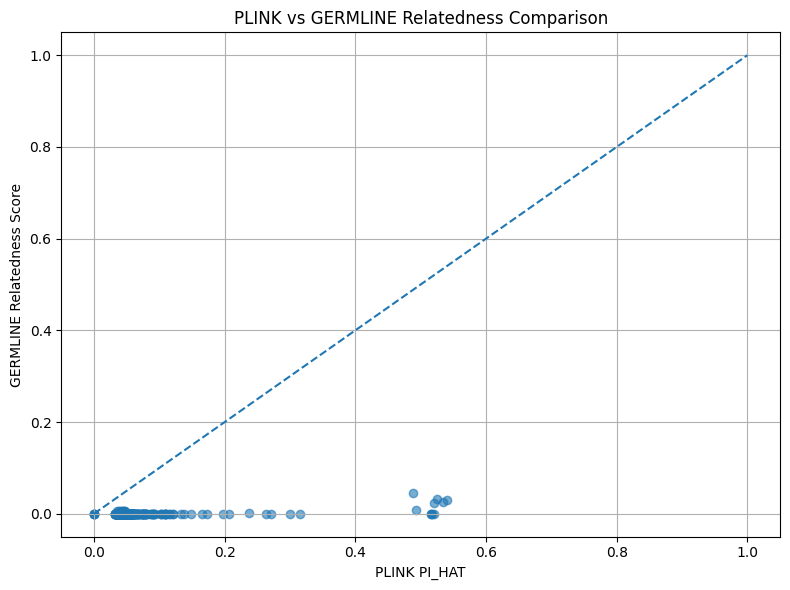

In [7]:
# ===============================
# Main
# ===============================

def main():

    print("Loading PLINK results...")
    plink_df = load_plink_results(PLINK_FILE)

    print("Loading GERMLINE results...")
    germline_raw = load_germline_results(GERMLINE_FILE)

    germline_df = compute_germline_relatedness(germline_raw)

    print("Merging datasets...")
    merged_df = merge_results(plink_df, germline_df)

    print(f"\nMatched pairs = {len(merged_df)}")

    analyze_results(merged_df)

    plot_scatter(merged_df)


if __name__ == "__main__":
    main()

## Runtime & Memory Usage: PLINK vs GERMLINE

Run the benchmark first from WSL:
```bash
conda activate bio_bench
bash benchmark.sh
```
This produces `benchmark_results.csv` with wall-clock time and peak RSS for each tool.

In [ ]:
# ===============================
# Load Benchmark Results
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BENCHMARK_FILE = "benchmark_results.csv"

bench = pd.read_csv(BENCHMARK_FILE)
bench["max_rss_mb"] = bench["max_rss_kb"] / 1024.0   # KB → MB

print(bench.to_string(index=False))


In [ ]:
# ===============================
# Runtime Comparison (Bar Chart)
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#4C72B0", "#DD8452"]

# --- Wall-clock time ---
axes[0].bar(bench["tool"], bench["wall_seconds"], color=colors)
axes[0].set_ylabel("Wall-Clock Time (seconds)")
axes[0].set_title("Runtime Comparison")
for i, v in enumerate(bench["wall_seconds"]):
    axes[0].text(i, v + 0.5, f"{v:.1f}s", ha="center", fontweight="bold")

# --- Peak memory ---
axes[1].bar(bench["tool"], bench["max_rss_mb"], color=colors)
axes[1].set_ylabel("Peak Memory (MB)")
axes[1].set_title("Memory Usage Comparison")
for i, v in enumerate(bench["max_rss_mb"]):
    axes[1].text(i, v + 0.5, f"{v:.1f} MB", ha="center", fontweight="bold")

plt.suptitle("PLINK vs GERMLINE: Performance Benchmark", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Summary ---
print("\n===== Performance Summary =====")
for _, row in bench.iterrows():
    print(f"{row['tool']:10s}  Wall: {row['wall_seconds']:.1f}s  |  "
          f"User: {row['user_seconds']:.1f}s  |  "
          f"Sys: {row['sys_seconds']:.1f}s  |  "
          f"Peak RSS: {row['max_rss_mb']:.1f} MB")

if len(bench) == 2:
    speedup = bench.iloc[1]["wall_seconds"] / bench.iloc[0]["wall_seconds"]
    mem_ratio = bench.iloc[1]["max_rss_mb"] / bench.iloc[0]["max_rss_mb"]
    faster = bench.iloc[0]["tool"] if speedup > 1 else bench.iloc[1]["tool"]
    leaner = bench.iloc[0]["tool"] if mem_ratio > 1 else bench.iloc[1]["tool"]
    print(f"\n{faster} is {max(speedup, 1/speedup):.1f}x faster")
    print(f"{leaner} uses {max(mem_ratio, 1/mem_ratio):.1f}x less memory")
